In [1]:
import cv2
import math
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt
mpl.rc('figure',  figsize=(20, 10))
mpl.rc('image', cmap='gray')

In [2]:
def extract_markers(thresh):
    # Extract markers from the thresholded image
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    markers = cv2.erode(thresh, kernel)
    markers = cv2.dilate(markers, kernel)
    return markers

In [3]:
def classify_froth(mean_size, num_spots):
    # Use the mean size and number of white spots as input features for the neural network classifier
    #froth_type = neural_network_classifier.predict(np.array([mean_size, num_spots]))
    froth_type = 7
    return froth_type


In [5]:
def update_pre_median_size(froth_type):
    # Update the size of the pre-median filter based on the froth type
    if froth_type == "foam":
        pre_median_size = 3
    elif froth_type == "froth":
        pre_median_size = 5
    else:
        pre_median_size = 7
    return pre_median_size


In [6]:
def determine_post_median_size(froth_type):
    # Determine the size of the post-median filter based on the froth type
    if froth_type == "foam":
        post_median_size = 3
    elif froth_type == "froth":
        post_median_size = 5
    else:
        post_median_size = 7
    return post_median_size

In [8]:
# Load the input image
image = cv2.imread('/kaggle/input/raw-image/bubble_raw.png', 0)
image2 = cv2.imread('/kaggle/input/raw-image/bubble_raw.png')

#image.shape
# Segment the froth image
#segmented_image = segment_froth_image(image, image2)


In [9]:
# Preprocess the image by applying a median filter and adaptive threshold
image = cv2.medianBlur(image, 3)
thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

# Extract white spots by identifying round objects in the processed image
circles = cv2.HoughCircles(thresh, cv2.HOUGH_GRADIENT, 1, 20, param1=50, param2=30, minRadius=0, maxRadius=0)

# Remove small objects
min_size = 5
white_spots = [spot for spot in circles[0] if spot[2] > min_size]

# Calculate the mean size and number of the extracted white spots
total_area = 0
num_spots = 0
for x, y, r in white_spots:
    area = math.pi * r * r
    total_area += area
    num_spots += 1
mean_size = total_area / num_spots if num_spots > 0 else 0

# Use the mean size and number of white spots as input features for the neural network classifier
froth_type = classify_froth(mean_size, num_spots)

# Update the size of the pre-median filter
pre_median_size = update_pre_median_size(froth_type)

# Determine the size of the post-median filter
post_median_size = determine_post_median_size(froth_type)

# Extract the first set of markers by applying the pre-median filter and adaptive threshold
image = cv2.medianBlur(image, pre_median_size)
thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

markers1 = extract_markers(thresh)



In [10]:
thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

markers1 = extract_markers(thresh)


In [11]:
# Extract the second set of markers by applying morphological operators on the smoothed original froth image
image = cv2.medianBlur(image, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
markers2 = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

# Extract the third set of markers by applying morphological operators on the smoothed original froth image
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
markers3 = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

In [23]:
# Smooth original image and extract second and third sets of markers using morphological operators
smooth = cv2.GaussianBlur(image, (5,5), 0)

markers2 = cv2.erode(smooth, None, iterations=3)
markers3 = cv2.dilate(smooth, None, iterations=3)

In [28]:
# Superimpose the sets of markers onto the topographic surface of the froth image
topo_image = 255 - thresh
markers = cv2.bitwise_or(markers1, markers2)
markers = cv2.bitwise_or(markers, markers3)
#markers = cv2.medianBlur(markers, post_median_size)
#topo_image = cv2.add(topo_image, markers)

# Filter the topographic image with the post-median filter
#topo_image = cv2.medianBlur(topo_image, post_median_size)


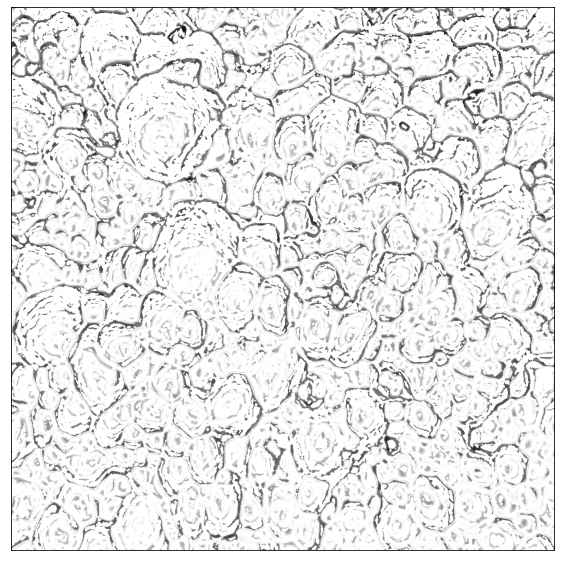

In [29]:
plt.imshow(markers)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()

In [156]:
# Invert processed image and apply watershed transform to smoothed topographic surface
inverted = cv2.bitwise_not(thresh)
smooth = cv2.GaussianBlur(inverted, (3,3), 0)
_, markers = cv2.connectedComponents(image_8u)
markers += 1
markers[inverted==255] = 0
markers = cv2.watershed(image2, markers)

# Create output image with different colors for each catchment basin
image2[markers == -1] = [255,0,0]
image2[markers > 0] = [0,255,0]

In [30]:
ret, thresh = cv2.threshold(image,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
markers = cv2.medianBlur(255-thresh, 7)


In [33]:
# Sobel Edge Detection
sobelx = cv2.Sobel(src=markers, ddepth=cv2.CV_64F, dx=1, dy=0, ksize=5) # Sobel Edge Detection on the X axis
sobely = cv2.Sobel(src=markers, ddepth=cv2.CV_64F, dx=0, dy=1, ksize=5) # Sobel Edge Detection on the Y axis
sobelxy = cv2.Sobel(src=markers, ddepth=cv2.CV_64F, dx=1, dy=1, ksize=5)

edges = cv2.Canny(image=markers, threshold1=100, threshold2=200) # Canny Edge Detection

In [42]:
edges = cv2.Canny(image=markers, threshold1=100, threshold2=200) # Canny Edge Detection

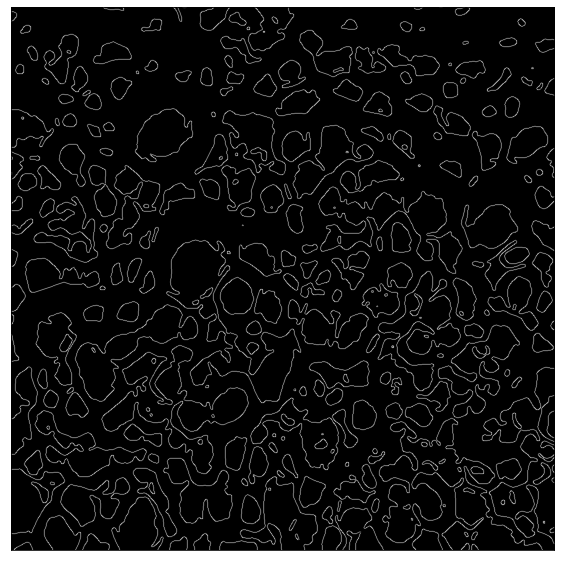

In [43]:
plt.imshow(edges)
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()

In [53]:
# Find connected components in the binary image
_, labels = cv2.connectedComponents(edges)

# Count the number of connected components
num_objects = labels.max()

# Find the size of each connected component
sizes = []
for i in range(1, num_objects+1):
    component = np.where(labels==i, 1, 0)
    size = np.sum(component)
    sizes.append(size)

# Calculate the mean size of the objects
mean_size = np.mean(sizes)

print(f'Number of objects detected: {num_objects}')
print(f'Mean size of objects: {mean_size}')

Number of objects detected: 301
Mean size of objects: 165.88372093023256
